In [1]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset
from gsnn_mds.subgroup.eval_subgroup import eval_subgroup

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests 

import seaborn as sbn 

%load_ext autoreload
%autoreload 2 

/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
  warnings.warn(msg)


# Drug-resistance/sensitivity by VAE cluster assignment


In [2]:
min_mds_mutation_frequency = 0.02       # mutation candidates must be present in at least X% of MDS patients 
min_drug_spearman_r = 0.5              # drug candidates must have strong predictive performance in MDS  
min_sample_size = 3                     # minimum number of MDS patients in subgroup 
exp_name = 'default_002'

In [3]:
mds_preds = pd.read_csv(f'mds_predictions_{exp_name}.csv', low_memory=False) 
gsnn_res = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{exp_name}/gsnn/stratified_results.csv')
ae_clusters = pd.read_csv('/home/teddy/local/data/evansmds/ae_clust.csv')

In [4]:
# filter to drugs that  have strong predictive performance in MDS 
gsnn_res2 = gsnn_res[lambda x: x.drug_combination != 'overall']
gsnn_res2 = gsnn_res2[lambda x: x.spearman_r > min_drug_spearman_r]
gsnn_res2 = gsnn_res2.assign(inhibitor_1 = [x if '+' not in x else x.split('+')[0] for x in gsnn_res2.drug_combination])
gsnn_res2 = gsnn_res2.assign(inhibitor_2 = [None if '+' not in x else x.split('+')[1] for x in gsnn_res2.drug_combination])

high_perf_inhibitor_candidates = gsnn_res2[['inhibitor_1', 'inhibitor_2']].drop_duplicates().reset_index(drop=True)

print('# drug candidates:', high_perf_inhibitor_candidates.shape[0])
print(set(high_perf_inhibitor_candidates.inhibitor_1.unique().tolist() + high_perf_inhibitor_candidates.inhibitor_2.unique().tolist()))

# drug candidates: 21
{'indisulam', ' otx-015', 'birinapant ', ' rapamycin', 'sunitinib', 'gsk-2879552', None, 'selumetinib (azd6244)', 'axitinib (ag-013736)', '17-aag (tanespimycin)', ' gw-2580', 'crenolanib', 'otx-015', 'rapamycin', 'tivozanib (av-951)', 'trametinib (gsk1120212)', 'foretinib (xl880)', 'dasatinib ', 'jq1', ' jq1', 'dasatinib', 'jnk inhibitor ii', 'gw-2580 ', 'go6976', 'motesanib (amg-706)'}


In [5]:
cluster_groups = {i:ae_clusters[ae_clusters.cons_clusters == i]['MLL ID'].unique().tolist() for i in ae_clusters.cons_clusters.unique().tolist()}

for cluster_id, members in cluster_groups.items(): 
    print(f'cluster {cluster_id}: {len(members)} genes')


cluster 1: 165 genes
cluster 5: 105 genes
cluster 3: 125 genes
cluster 6: 48 genes
cluster 7: 69 genes
cluster 2: 58 genes
cluster 4: 89 genes


In [6]:
res = []
for i, cluster_ids in cluster_groups.items(): 
    print(f'progress: [cluster: {i}]')
    res.append(eval_subgroup(mds_preds, cluster_ids, high_perf_inhibitor_candidates, f'cluster_{i}', min_sample_size))

res = pd.concat(res)
res = res.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res.head() 


progress: [cluster: 1]
progress: [cluster: 5]
progress: [cluster: 3]
progress: [cluster: 6]
progress: [cluster: 7]
progress: [cluster: 2]
progress: [cluster: 4]


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,test_stat,subgroup_n,rest_n,test_method,subgroup,mean_diff,fdr
0,17-aag (tanespimycin),None,-0.526935,0.319306,-0.588370,0.322673,2.973854e-02,47533.0,165,518,mannwhitneyu,cluster_1,0.061435,5.801454e-02
1,axitinib (ag-013736),None,0.184902,0.326136,0.070546,0.329494,6.802871e-05,51527.0,165,518,mannwhitneyu,cluster_1,0.114356,3.113622e-04
2,crenolanib,None,0.367011,0.231167,0.375052,0.279230,8.347339e-01,42274.0,165,518,mannwhitneyu,cluster_1,-0.008041,8.948949e-01
3,dasatinib,None,-0.118987,0.463413,-0.397029,0.457281,5.106945e-11,57232.0,165,518,mannwhitneyu,cluster_1,0.278041,2.025755e-09
4,foretinib (xl880),None,-1.155545,0.311022,-1.110037,0.357091,1.355403e-01,39440.0,165,518,mannwhitneyu,cluster_1,-0.045508,2.209493e-01


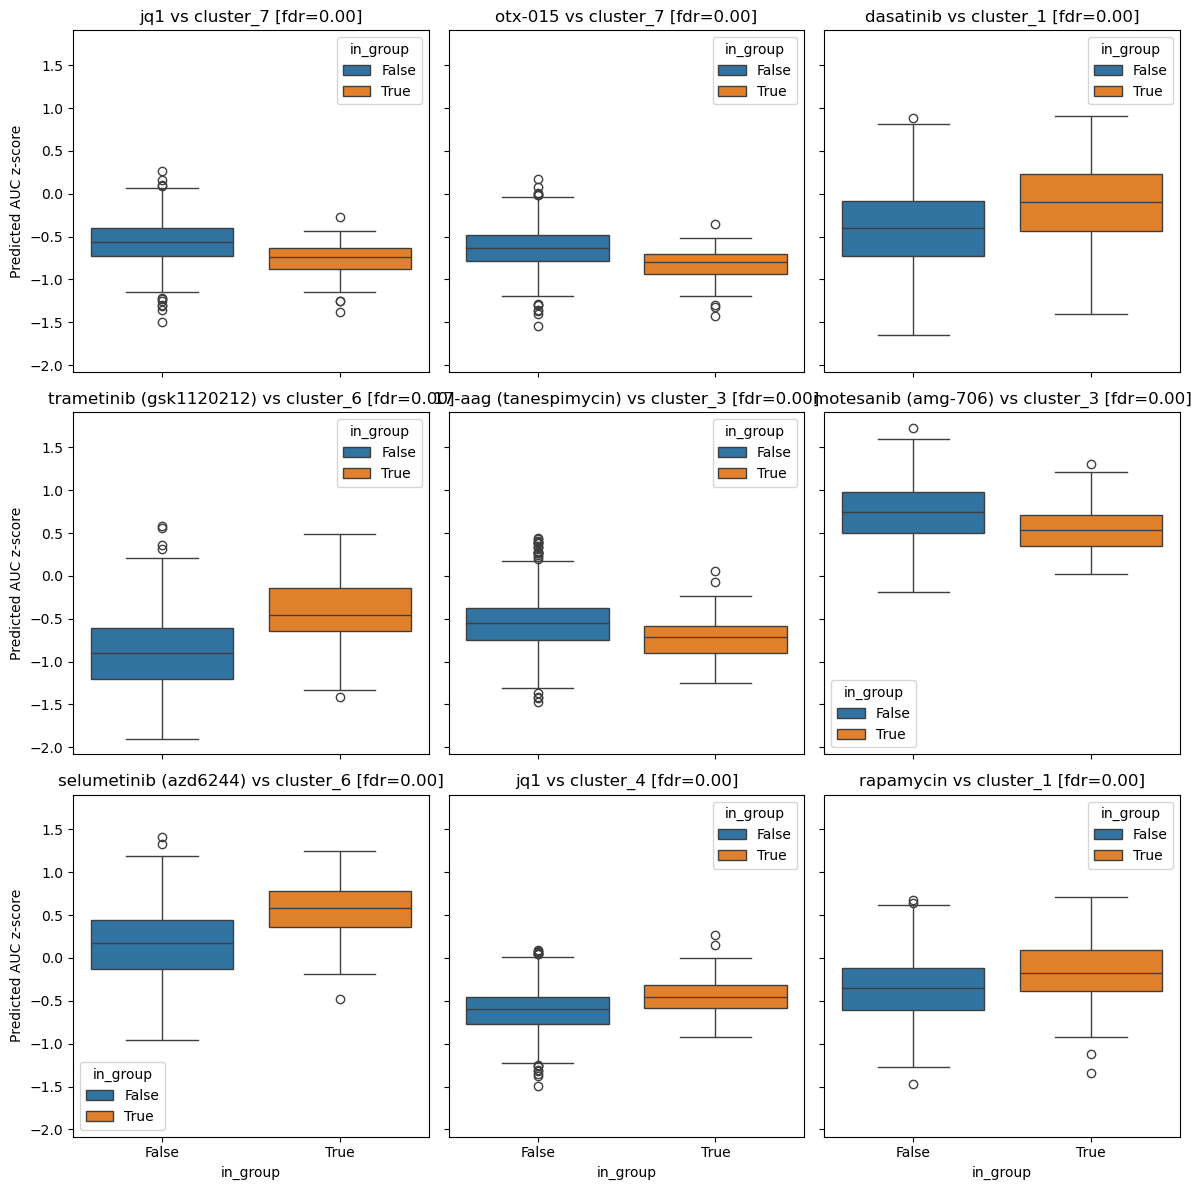

,drug1,drug2,subgroup,test_stat,fdr,mean_diff,subgroup_n
13,jq1,None,cluster_7,10668.0,7.868423e-10,-0.215490,69
14,otx-015,None,cluster_7,10570.0,7.868423e-10,-0.208436,69
3,dasatinib,None,cluster_1,57232.0,2.025755e-09,0.278041,165
12,trametinib (gsk1120212),None,cluster_6,23463.0,1.316877e-08,0.449663,48
0,17-aag (tanespimycin),None,cluster_3,22665.0,2.180892e-08,-0.187060,125
7,motesanib (amg-706),None,cluster_3,22783.0,2.630795e-08,-0.200721,125
9,selumetinib (azd6244),None,cluster_6,23185.0,2.834543e-08,0.387260,48
13,jq1,None,cluster_4,36578.0,7.583797e-08,0.179715,89
8,rapamycin,None,cluster_1,55570.0,8.026807e-08,0.186169,165
14,otx-015,None,cluster_4,36111.0,2.947201e-07,0.166430,89


In [7]:
top_hits = res.sort_values('fdr', ascending=True)

fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in top_hits.head(9).reset_index(drop=True).iterrows(): 

    subgroup_ids = cluster_groups[int(row.subgroup.split('_')[-1])]
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {row.subgroup} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

top_hits[['drug1', 'drug2', 'subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']].head(10)

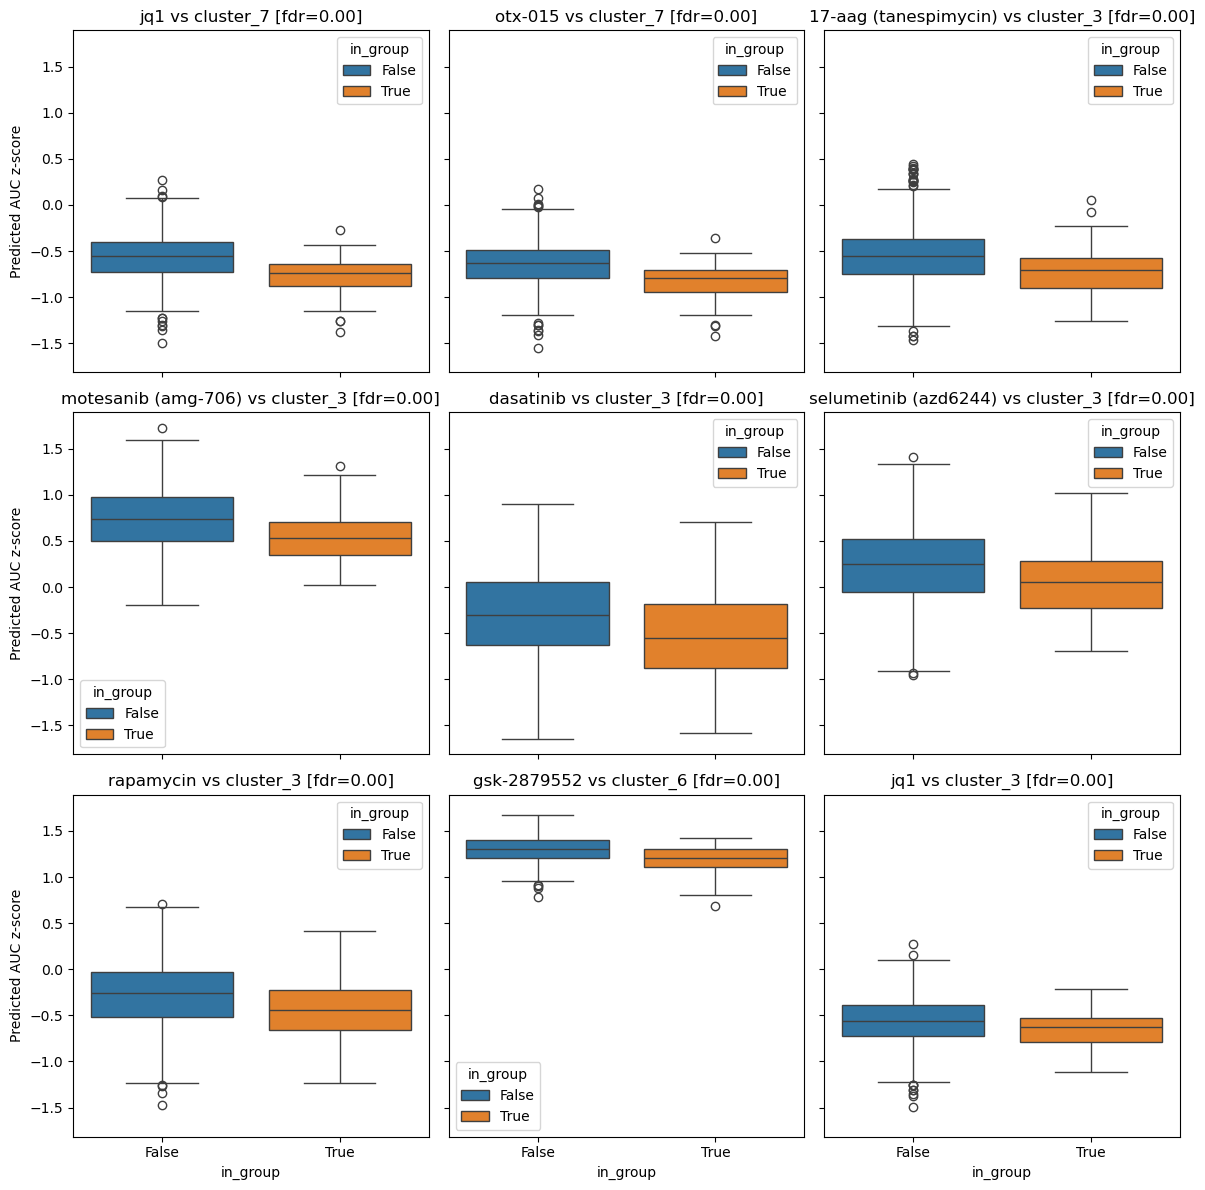

,drug1,drug2,subgroup,test_stat,fdr,mean_diff,subgroup_n
13,jq1,None,cluster_7,10668.0,7.868423e-10,-0.215490,69
14,otx-015,None,cluster_7,10570.0,7.868423e-10,-0.208436,69
0,17-aag (tanespimycin),None,cluster_3,22665.0,2.180892e-08,-0.187060,125
7,motesanib (amg-706),None,cluster_3,22783.0,2.630795e-08,-0.200721,125
3,dasatinib,None,cluster_3,24777.0,4.068636e-06,-0.243245,125
9,selumetinib (azd6244),None,cluster_3,25318.0,1.397989e-05,-0.190479,125
8,rapamycin,None,cluster_3,25305.0,1.397989e-05,-0.170834,125
16,gsk-2879552,None,cluster_6,9205.0,3.487859e-05,-0.116145,48
13,jq1,None,cluster_3,26317.0,1.054620e-04,-0.107605,125
12,trametinib (gsk1120212),None,cluster_3,26465.0,1.335866e-04,-0.182871,125


In [8]:
top_sensitive_hits = res.sort_values('fdr', ascending=True)[lambda x: (x.mean_diff < 0)]

fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in top_sensitive_hits.head(9).reset_index(drop=True).iterrows(): 

    subgroup_ids = cluster_groups[int(row.subgroup.split('_')[-1])]
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {row.subgroup} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

top_sensitive_hits[['drug1', 'drug2', 'subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']].head(10)

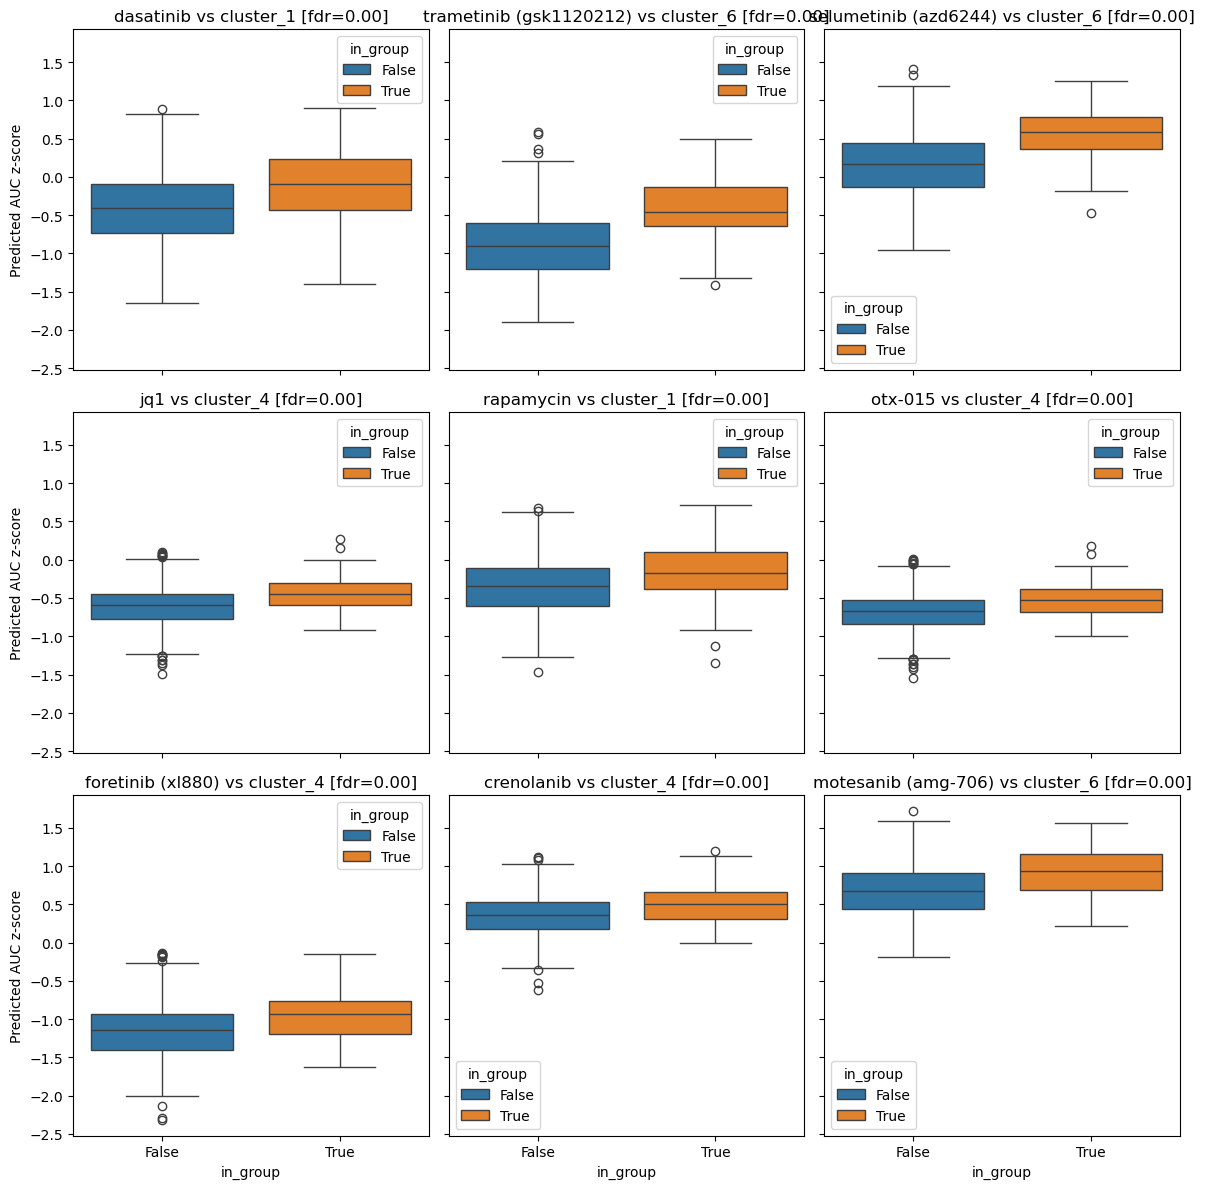

,drug1,drug2,subgroup,test_stat,fdr,mean_diff,subgroup_n
3,dasatinib,None,cluster_1,57232.0,2.025755e-09,0.278041,165
12,trametinib (gsk1120212),None,cluster_6,23463.0,1.316877e-08,0.449663,48
9,selumetinib (azd6244),None,cluster_6,23185.0,2.834543e-08,0.387260,48
13,jq1,None,cluster_4,36578.0,7.583797e-08,0.179715,89
8,rapamycin,None,cluster_1,55570.0,8.026807e-08,0.186169,165
14,otx-015,None,cluster_4,36111.0,2.947201e-07,0.166430,89
4,foretinib (xl880),None,cluster_4,35380.0,2.761460e-06,0.209805,89
2,crenolanib,None,cluster_4,34652.0,1.742802e-05,0.150465,89
7,motesanib (amg-706),None,cluster_6,21223.0,3.960906e-05,0.239953,48
3,dasatinib,None,cluster_6,21181.0,4.348860e-05,0.300558,48


In [9]:
top_resistant_hits = res.sort_values('fdr', ascending=True)[lambda x: (x.mean_diff > 0)]

fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in top_resistant_hits.head(9).reset_index(drop=True).iterrows(): 

    subgroup_ids = cluster_groups[int(row.subgroup.split('_')[-1])]
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {row.subgroup} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

top_resistant_hits[['drug1', 'drug2', 'subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']].head(10)

In [10]:
res.sort_values('fdr', ascending=True)[lambda x: (x.mean_diff > 0)][lambda x: x.drug1 == 'venetoclax']


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,test_stat,subgroup_n,rest_n,test_method,subgroup,mean_diff,fdr


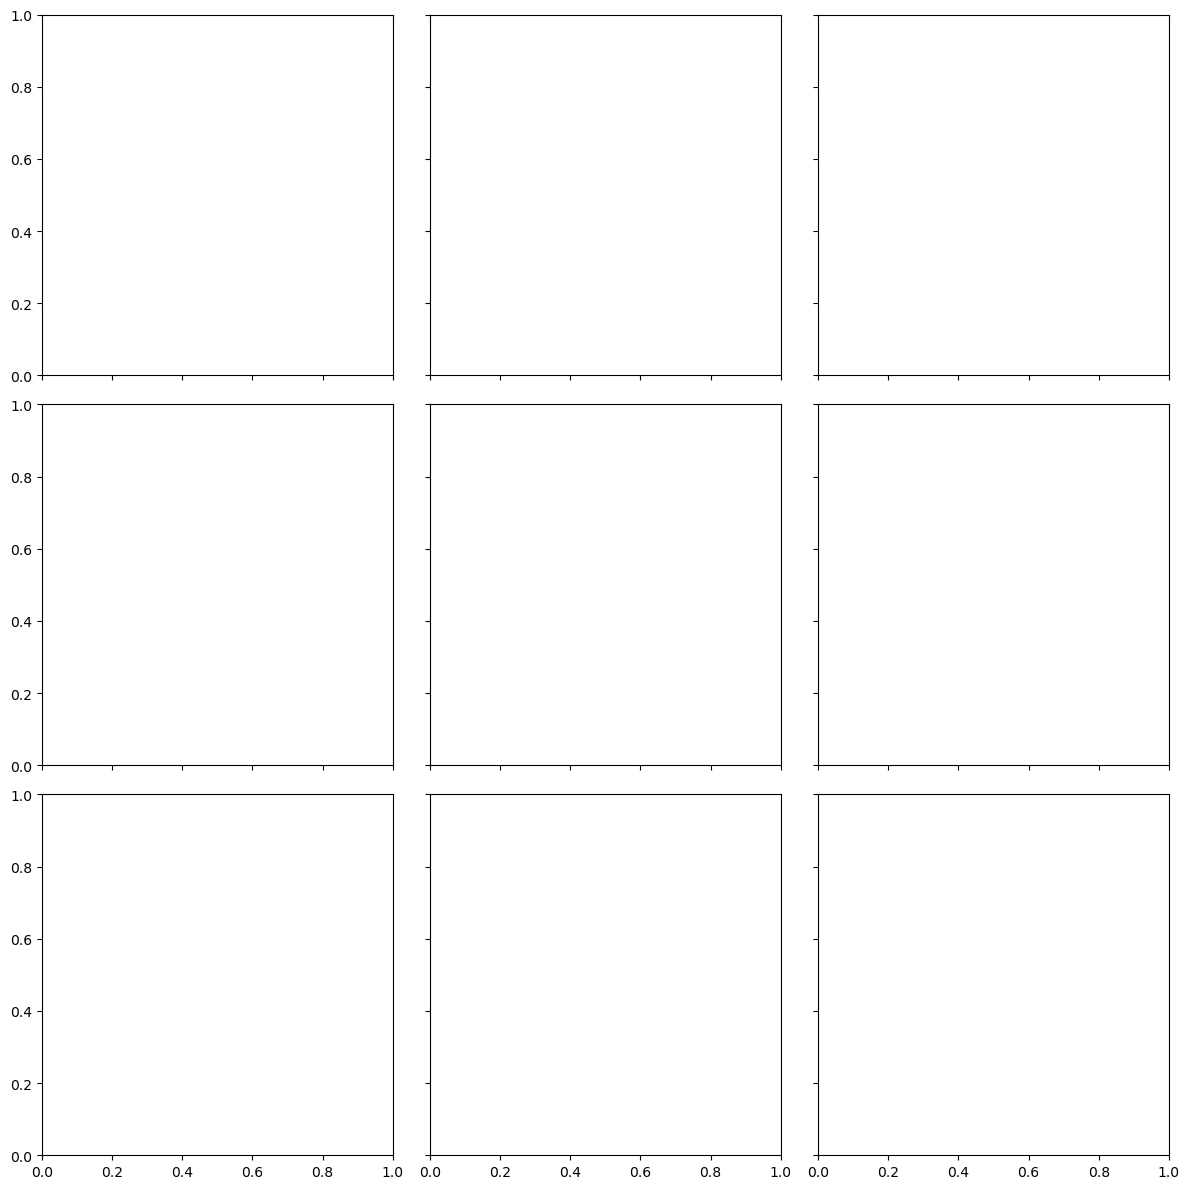

,drug1,drug2,subgroup,test_stat,fdr,mean_diff,subgroup_n


In [11]:
top_ven_hits = res[lambda x: x.drug1 == 'venetoclax'].sort_values('fdr', ascending=True)

fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in top_ven_hits.head(9).reset_index(drop=True).iterrows(): 

    subgroup_ids = cluster_groups[int(row.subgroup.split('_')[-1])]
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {row.subgroup} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

top_ven_hits[['drug1', 'drug2', 'subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']].head(10) 

# Cluster 1 and 6 are both sensitive to Venetoclax

Plot the those clusters together

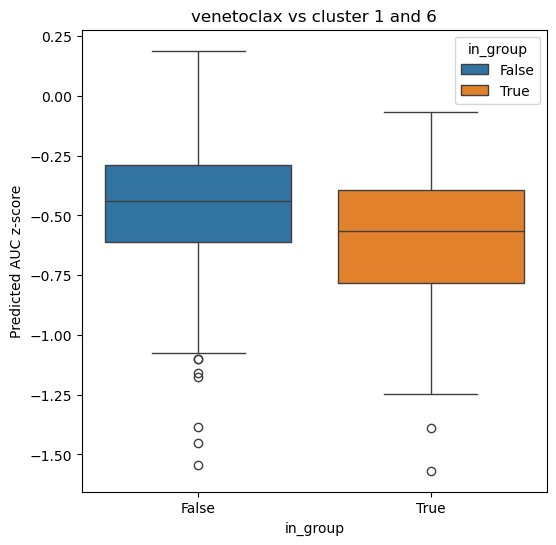

venetoclax delta AUC mean diff (cluster 1 + 6 vs rest): -0.14
p-value (ttest): 2.39e-09
subgroup mean, std:  -0.6005087335211268 0.28520334882416437
rest mean, std:  -0.4612337238907447 0.2506552289103899


In [12]:
fig, axes = plt.subplots(1,1, figsize=(6, 6), sharey=True, sharex=True)

subgroup_ids = cluster_groups[1] + cluster_groups[6] 
tmp = mds_preds[lambda x: (x.inhibitor_1 == 'venetoclax') & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

axes.set_title(f'venetoclax vs cluster 1 and 6')
sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes) 
axes.set_ylabel('Predicted AUC z-score')

plt.show() 

in_grp_yhat = tmp[lambda x: x.in_group].yhat.values 
out_grp_yhat = tmp[lambda x: ~x.in_group].yhat.values 

tres = ttest_ind(in_grp_yhat, out_grp_yhat, equal_var=False)
delta_yhat = in_grp_yhat.mean() - out_grp_yhat.mean()

print(f'venetoclax delta AUC mean diff (cluster 1 + 6 vs rest): {delta_yhat:.2f}')
print(f'p-value (ttest): {tres.pvalue:.2e}')
print('subgroup mean, std: ', in_grp_yhat.mean(), in_grp_yhat.std())
print('rest mean, std: ', out_grp_yhat.mean(), out_grp_yhat.std())


/tmp/ipykernel_16554/2824931584.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


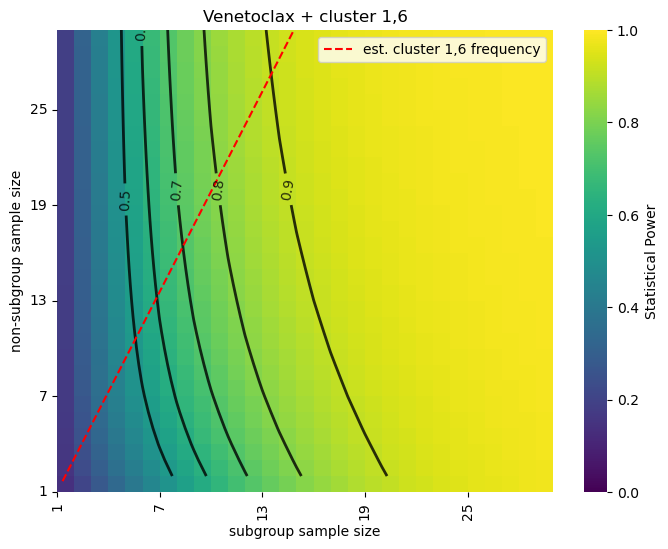

In [13]:
from gsnn_mds.subgroup.power_calc import power_two_sample_z

title = 'Venetoclax + cluster 1,6'

a_mu = -0.8468    # _predicted mutation subgroup mean 
a_std =0.23  # _predicted mutation subgroup std 
b_mu = -0.62  # _predicted non-mutation subgroup mean 
b_std = 0.21 # _predicted non-mutation subgroup std 

nn = 30

n_as_ = np.arange(1,nn)
n_bs = np.arange(1,nn)

powers = []
for n_a_ in n_as_: 
    ps = []
    for n_b in n_bs: 

        n_a = n_b + n_a_

        #if n_a <=  n_b: 
        #    ps.append(None) 

        #else: 
        power = power_two_sample_z(a_mu, a_std, b_mu, b_std, n_a, n_b, alpha=0.05, alternative='two-sided')
        ps.append(power)

    powers.append(ps)

powers = np.array(powers)
pow_df = pd.DataFrame(powers, index=n_as_, columns=n_bs)

plt.figure(figsize=(8, 6))
ax = sbn.heatmap(pow_df.fillna(-1), cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'Statistical Power'})
plt.xlabel('subgroup sample size')
plt.ylabel('non-subgroup sample size')

# add contour lines 
X, Y = np.meshgrid(n_bs, n_as_)
contours = plt.contour(X, Y, powers, levels=[0.5, 0.6, 0.7, 0.8, 0.9], colors='k', linewidths=2, alpha=0.8)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

# invert y-axis so 1 is at the bottom
ax.invert_yaxis()

# space out tick labels
plt.xticks(np.arange(0, nn, nn//5), np.arange(1, nn+1, nn//5))
plt.yticks(np.arange(0, nn, nn//5), np.arange(1, nn+1, nn//5))

plt.title(title)
plt.legend()

# add line based on frequency of cluster 1 and 6 
clust16_freq = (len(cluster_groups[1]) + len(cluster_groups[6])) / ae_clusters.shape[0]
tot_nn = np.arange(1, 50)
xx = tot_nn * clust16_freq
yy = tot_nn * (1 - clust16_freq)

plt.plot(xx, yy, 'r--', label='est. cluster 1,6 frequency')

plt.legend() 
plt.show()


In [14]:
clust16_freq

0.3232169954476479

# Venetoclax combination predictions (Ven + ?)

In [15]:
import itertools

good_single_agents = high_perf_inhibitor_candidates[lambda x: x.inhibitor_2.isna()].inhibitor_1.unique().tolist()

ven_comb_candidates = {'inhibitor_1':[], 'inhibitor_2':[]} 
for i, inhibitor in enumerate(good_single_agents): 
    if inhibitor == 'venetoclax': 
        continue 
    ven_comb_candidates['inhibitor_1'].append('venetoclax')
    ven_comb_candidates['inhibitor_2'].append(inhibitor)

ven_comb_candidates = pd.DataFrame(ven_comb_candidates)
ven_comb_candidates.shape


(17, 2)

In [16]:

res_ven = []
for cluster_id, cluster_members in cluster_groups.items(): 
    print(f'progress: {cluster_id}/{len(cluster_groups)} [cluster: {cluster_id}]')
    res_ven.append(eval_subgroup(mds_preds, cluster_members, ven_comb_candidates, f'cluster_{cluster_id}'))

res_ven = pd.concat(res_ven)
res_ven = res_ven.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res_ven.head() 


progress: 1/7 [cluster: 1]
progress: 5/7 [cluster: 5]
progress: 3/7 [cluster: 3]
progress: 6/7 [cluster: 6]
progress: 7/7 [cluster: 7]
progress: 2/7 [cluster: 2]
progress: 4/7 [cluster: 4]


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,test_stat,subgroup_n,rest_n,test_method,subgroup,mean_diff,fdr
0,venetoclax,17-aag (tanespimycin),-1.444905,0.177925,-1.437151,0.207406,7.478724e-01,42025.0,165,518,mannwhitneyu,cluster_1,-0.007753,8.164845e-01
1,venetoclax,axitinib (ag-013736),-0.963868,0.198694,-1.007334,0.237152,2.406986e-02,47715.0,165,518,mannwhitneyu,cluster_1,0.043466,4.212226e-02
2,venetoclax,crenolanib,-0.729328,0.205367,-0.663962,0.269013,1.446348e-03,35704.0,165,518,mannwhitneyu,cluster_1,-0.065366,3.247462e-03
3,venetoclax,dasatinib,-1.643440,0.268455,-1.797456,0.263053,1.361967e-10,56906.0,165,518,mannwhitneyu,cluster_1,0.154015,7.046701e-10
4,venetoclax,foretinib (xl880),-2.367645,0.203358,-2.325184,0.227926,2.350817e-02,37735.0,165,518,mannwhitneyu,cluster_1,-0.042461,4.212226e-02


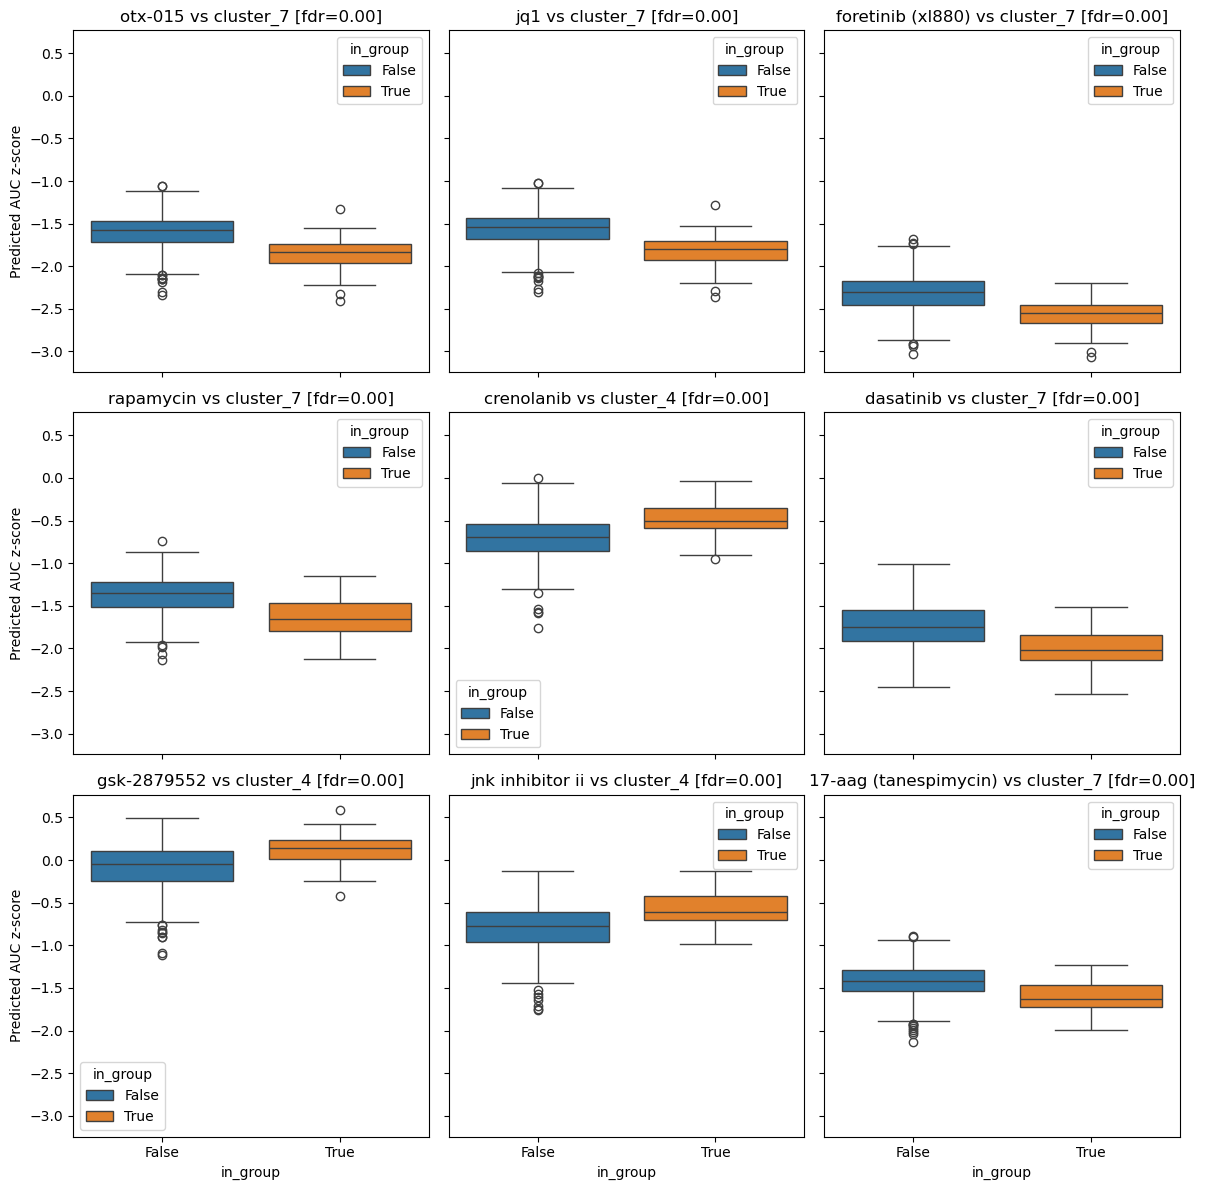

,drug1,drug2,subgroup,test_stat,fdr,mean_diff,subgroup_n
14,venetoclax,otx-015,cluster_7,6636.0,9.418269e-19,-0.259406,69
13,venetoclax,jq1,cluster_7,6787.0,1.175848e-18,-0.259370,69
4,venetoclax,foretinib (xl880),cluster_7,7764.0,2.331342e-16,-0.245607,69
8,venetoclax,rapamycin,cluster_7,8107.0,1.176999e-15,-0.271941,69
2,venetoclax,crenolanib,cluster_4,40485.0,1.367034e-14,0.233003,89
3,venetoclax,dasatinib,cluster_7,9272.0,3.560660e-13,-0.262522,69
16,venetoclax,gsk-2879552,cluster_4,39225.0,2.927255e-12,0.207178,89
6,venetoclax,jnk inhibitor ii,cluster_4,39188.0,3.004669e-12,0.214962,89
0,venetoclax,17-aag (tanespimycin),cluster_7,9808.0,3.289007e-12,-0.191531,69
15,venetoclax,indisulam,cluster_4,38976.0,5.948089e-12,0.213511,89


In [17]:
top_ven_comb_hits = res_ven.sort_values('fdr', ascending=True)

fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in top_ven_comb_hits.head(9).reset_index(drop=True).iterrows(): 

    subgroup_ids = cluster_groups[int(row.subgroup.split('_')[-1])]
    tmp = mds_preds[lambda x: (x.inhibitor_1 == 'venetoclax') & (x.inhibitor_2 == row.drug2)].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug2} vs {row.subgroup} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

top_ven_comb_hits[['drug1', 'drug2', 'subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']].head(15)

In [23]:
tmp1.head()

NameError: name 'tmp1' is not defined

# Ven. combination Synergy (within subgroups) 

In [ ]:
res_all = pd.concat([res, res_ven])

def get_synergy(drug1, drug2, subgroup): 


    tmp1 = res_all[lambda x: (x.drug1 == drug1) & (x.drug2.isna()) & (x.subgroup == subgroup)]
    tmp2 = res_all[lambda x: (x.drug1 == drug2) & (x.drug2.isna()) & (x.subgroup == subgroup)]
    tmp12 = res_all[lambda x: (x.drug1 == drug1) & (x.drug2 == drug2) & (x.subgroup == subgroup)]

    print(tmp1.head())
    print(tmp2.head())
    print(tmp12.head())
    3/0

    delta_improvement_synergy = tmp12.mean_diff.mean() - min(tmp1.mean_diff.mean(), tmp2.mean_diff.mean())
    
    syn_dict = {'synergy':delta_improvement_synergy, 'drug1_mean_diff':tmp1.mean_diff.mean(), 'drug2_mean_diff':tmp2.mean_diff.mean(), 'drug12_mean_diff':tmp12.mean_diff.mean()}
    return syn_dict 


drug1 = 'venetoclax'  

syn_res = {'drug1':[], 'drug2':[], 'subgroup':[], 'synergy':[], 'drug1_mean_diff':[], 'drug2_mean_diff':[], 'drug12_mean_diff':[]}
for drug2 in res_all.drug2.unique().tolist(): 
    for mut in res_all.subgroup.unique().tolist(): 
        if drug2 == None: continue  
        syn_res['drug1'].append(drug1)
        syn_res['drug2'].append(drug2)
        syn_res['subgroup'].append(mut)
        syn_dict = get_synergy(drug1, drug2, mut)
        syn_res['synergy'].append(syn_dict['synergy'])
        syn_res['drug1_mean_diff'].append(syn_dict['drug1_mean_diff'])
        syn_res['drug2_mean_diff'].append(syn_dict['drug2_mean_diff'])
        syn_res['drug12_mean_diff'].append(syn_dict['drug12_mean_diff'])

syn_res = pd.DataFrame(syn_res)
syn_res.sort_values('synergy', ascending=True).head(20)



Empty DataFrame
Columns: [drug1, drug2, subgroup_y_mean, subgroup_y_std, rest_y_mean, rest_y_std, pval, test_stat, subgroup_n, rest_n, test_method, subgroup, mean_diff, fdr]
Index: []
                   drug1 drug2  subgroup_y_mean  subgroup_y_std  rest_y_mean  \
0  17-aag (tanespimycin)  None        -0.526935        0.319306     -0.58837   

   rest_y_std      pval  test_stat  subgroup_n  rest_n   test_method  \
0    0.322673  0.029739    47533.0         165     518  mannwhitneyu   

    subgroup  mean_diff       fdr  
0  cluster_1   0.061435  0.058015  
        drug1                  drug2  subgroup_y_mean  subgroup_y_std  \
0  venetoclax  17-aag (tanespimycin)        -1.444905        0.177925   

   rest_y_mean  rest_y_std      pval  test_stat  subgroup_n  rest_n  \
0    -1.437151    0.207406  0.747872    42025.0         165     518   

    test_method   subgroup  mean_diff       fdr  
0  mannwhitneyu  cluster_1  -0.007753  0.816485  


ZeroDivisionError: division by zero

In [ ]:
syn_res.sort_values('synergy', ascending=True)[lambda x: x.subgroup.isin(['cluster_1', 'cluster_6'])].head(15).dropna()

,drug1,drug2,subgroup,synergy,drug1_mean_diff,drug2_mean_diff,drug12_mean_diff
